# Useful Filtering for Computational Neuroscience

## A 'recursive' estimator in the scalar case

Suppose there is a hidden scalar quantity $x$ that does not change with time, but we cannot observe it directly. Instead, at each time step we observe

$$
y_t = x + w_t,
$$

where $w_t$ is observation noise.

We now build a recursive estimate $\hat x_t$ from repeated observations. Starting from some initial guess $\hat x_0$, we update by

$$
\hat x_{t+1} = \hat x_t + K\,(y_t - \hat x_t).
$$

Here, $y_t - \hat x_t$ is the current mismatch between observation and estimate, and $K$ controls how strongly the estimate reacts to that mismatch.

- If $K$ is larger, the estimate reacts more strongly to each new observation.
- If $K$ is smaller, the estimate changes more slowly and is less sensitive to individual observations.

In the plots below, we will compare four settings:
- low observation noise with small $K$,
- low observation noise with large $K$,
- high observation noise with small $K$,
- high observation noise with large $K$.

Each panel shows the estimated value over time under continuous observation, together with the true hidden value shown as a dotted reference line.

**Question for students:**  
What differences do you observe between the four cases?  
How do the noise level and the choice of $K$ jointly affect speed of adaptation and variability of the estimate?

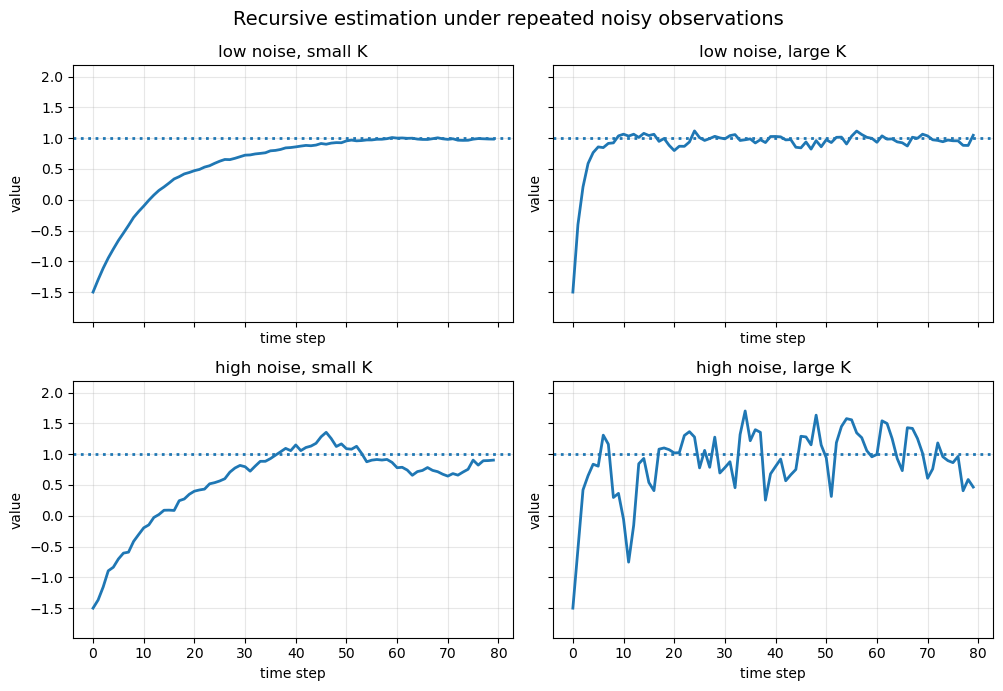

In [ ]:
# Don't Edit (Unless You've Finished the Whole Notebook and Understand the Content Well)

import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
rng = np.random.default_rng(7)

# Hidden scalar value
x_true = 1.0

# Time axis
T = 80
t = np.arange(T)

# Initial estimate
x0 = -1.5

# Four cases: (noise_std, K, title)
cases = [
    (0.15, 0.08, "low noise, small K"),
    (0.15, 0.45, "low noise, large K"),
    (0.80, 0.08, "high noise, small K"),
    (0.80, 0.45, "high noise, large K"),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
axes = axes.ravel()

all_estimates = []

for ax, (noise_std, K, panel_title) in zip(axes, cases):
    # Continuous observations
    y = x_true + rng.normal(0.0, noise_std, size=T)

    # Recursive estimate
    x_hat = np.zeros(T)
    x_hat[0] = x0
    for i in range(T - 1):
        x_hat[i + 1] = x_hat[i] + K * (y[i] - x_hat[i])

    all_estimates.append(x_hat)

    # Plot estimate and true value
    ax.plot(t, x_hat, linewidth=2, label="estimate")
    ax.axhline(x_true, linestyle=":", linewidth=2, label="true value")
    ax.set_title(panel_title)
    ax.set_xlabel("time step")
    ax.set_ylabel("value")
    ax.grid(alpha=0.3)

# Make y-limits consistent and readable
y_min = min(np.min(est) for est in all_estimates)
y_max = max(np.max(est) for est in all_estimates)
pad = 0.15 * (y_max - y_min + 1e-8)
for ax in axes:
    ax.set_ylim(min(y_min, x_true) - pad, max(y_max, x_true) + pad)

fig.suptitle("Recursive estimation under repeated noisy observations", fontsize=14)
fig.tight_layout()
plt.show()

## Why use a recursive estimator?

You may wonder: why not simply take the average of all observations, or use a moving average over a recent time window?

Those approaches can be useful in some stationary settings, where the hidden quantity is roughly constant and old observations remain as relevant as new ones. In that case, collecting more data can steadily reduce uncertainty.

However, many systems of interest are not stationary. Their hidden states evolve with time. In that setting, two difficulties appear.

### 1. Old data gradually become unreliable

If the hidden state changes, then measurements from the distant past are no longer direct evidence about the current state. A simple average treats all past observations too similarly, and can therefore lag behind the current situation.

A moving average partly addresses this by discarding older data, but the window length must be chosen by hand. If the system changes at different speeds over time, one fixed window may not work well in all regimes.

A recursive estimator handles this more naturally: at each step, it combines the current estimate with the new observation, so that past information is kept only through the current estimate rather than through the entire raw history.

### 2. Storing and reusing long histories can become costly

If we insist on using the full observation history directly, then each new estimate depends on a growing amount of stored data. This can become inconvenient both conceptually and computationally.

A recursive form avoids carrying the whole past explicitly. Instead, it compresses the relevant information from previous observations into the current estimate. This is especially useful when the estimate will be used again in later computations, since we do not want every future step to depend on an ever-growing chain of past observations.

### The inherited target from the previous example

In the previous example, we already used the update rule

$$
\hat x_{t+1} = \hat x_t + K (y_t - \hat x_t).
$$

This was not only a convenient rule. It was also trying to achieve the same target at every step: produce an estimate that is close to the hidden quantity.

A natural objective is therefore to minimize the expected squared estimation error,

$$
\mathbb E \big[(x - \hat x_t)^2\big].
$$

For a time-varying hidden state, this becomes

$$
\mathbb E \big[(x_t - \hat x_t)^2\big].
$$

So the recursive estimator is not just a memory-saving trick. It is a way to update our estimate over time while still aiming at the same inherited goal: make the current estimate as accurate as possible in mean-square error.

This will later lead us to a more systematic question:

**How should we choose the update strength so that the estimate balances old belief and new evidence in an optimal way?**

## Choosing the update strength using variance

We now return to the scalar update rule

$$
\hat x_{t+1} = \hat x_t + K (y_t - \hat x_t).
$$

Since the observation model is

$$
y_t = x + w_t,
$$

we can rewrite the update as

$$
\begin{aligned}
\hat x_{t+1}
=& \hat x_t + K(x + w_t - \hat x_t) \\\\
=& (1-K)\hat x_t + Kx + Kw_t.
\end{aligned}
$$

To choose $K$ well, we want the new estimate $\hat x_{t+1}$ to be as close as possible to the true hidden value $x$, on average.

Define the estimation error at time $t$ by

$$
e_t = x - \hat x_t.
$$

Then

$$
\begin{aligned}
e_{t+1}
=& x - \hat x_{t+1}  \\\\
=& x - \big((1-K)\hat x_t + Kx + Kw_t\big)  \\\\
=& (1-K)(x-\hat x_t) - Kw_t  \\\\
=& (1-K)e_t - Kw_t.
\end{aligned}
$$

Assume that

- the current estimate is unbiased enough that we focus on its variance,
- the observation noise $w_t$ has mean $0$ and variance $\sigma^2$,
- $e_t$ and $w_t$ are uncorrelated.

Let

$$
P_t = \mathrm{Var}(e_t) = \mathbb E[e_t^2].
$$

This quantity measures how uncertain the current estimate is. Since we are still in the scalar case, $P_t$ is just a number.

Using the error update,

$$
e_{t+1} = (1-K)e_t - Kw_t,
$$

the variance at the next step is

$$
P_{t+1}
= \mathrm{Var}(e_{t+1})
= \mathrm{Var}\big((1-K)e_t - Kw_t\big).
$$

Because $e_t$ and $w_t$ are uncorrelated,

$$
P_{t+1}
= (1-K)^2 \mathrm{Var}(e_t) + K^2 \mathrm{Var}(w_t)
= (1-K)^2 P_t + K^2 \sigma^2.
$$

So the choice of $K$ controls the next-step uncertainty through

$$
P_{t+1}(K) = (1-K)^2 P_t + K^2 \sigma^2.
$$

We now choose $K$ to minimize this quantity.

Take derivative with respect to $K$:

$$
\frac{dP_{t+1}}{dK}
=
2(1-K)(-1)P_t + 2K\sigma^2
=
-2(1-K)P_t + 2K\sigma^2.
$$

Set this equal to zero:

$$
-2(1-K)P_t + 2K\sigma^2 = 0.
$$

Tidy up:

$$
K(P_t + \sigma^2) = P_t,
$$

and therefore the optimal choice is

$$
K^\star = \frac{P_t}{P_t + \sigma^2}.
$$

The second derivative is

$$
\frac{d^2P_{t+1}}{dK^2} = 2P_t + 2\sigma^2 > 0,
$$

so this is indeed a minimum.

### Interpretation

The optimal update strength is

$$
K^\star = \frac{P_t}{P_t + \sigma^2}.
$$

This has a very natural meaning:

- if $P_t$ is large, the current estimate is uncertain, so we should trust the new observation more, making $K$ larger;
- if $\sigma^2$ is large, the observation is noisy, so we should trust it less, making $K$ smaller.

Substituting this optimal choice back into the update rule gives

$$
\hat x_{t+1} = \hat x_t + \frac{P_t}{P_t+\sigma^2}(y_t-\hat x_t).
$$

So the update strength is not arbitrary: it can be derived directly by minimizing the next-step estimation variance.

**You can now play with different K options and see their performance. Relax, no question will be asked here.**

In [10]:
# Don't Edit (Unless You've Finished the Whole Notebook and Understand the Content Well)

import warnings
from collections.abc import Callable
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.style as style 
style.use('tableau-colorblind10')


def run_scalar_recursive_demo(
    K_functions: dict,
    *,
    x_true: float = 1.0,
    x0: float = -1.5,
    T: int = 80,
    noise_stds = (0.15, 0.80),
    P0: float = 1.0,
    seed: int = 7,
    figsize: tuple[float, float] = (12, 8),
):
    """
    Simulate scalar recursive estimation for multiple choices of K(P, sigma).

    Parameters
    ----------
    K_functions : dict
        Keys are display names, values are callables:
            f(P, sigma) -> scalar K
    x_true : float
        Hidden fixed scalar.
    x0 : float
        Initial estimate.
    T : int
        Number of time steps.
    noise_stds : iterable
        Standard deviations sigma used in the observation noise.
    P0 : float
        Initial uncertainty of the estimate.
    seed : int
        Random seed for reproducibility.
    figsize : tuple
        Figure size passed to matplotlib.

    Returns
    -------
    results : dict
        Nested dictionary containing trajectories and diagnostic quantities.
    """
    if not isinstance(K_functions, dict) or len(K_functions) == 0:
        raise ValueError("K_functions must be a non-empty dict of name -> callable.")

    for name, fn in K_functions.items():
        if not callable(fn):
            raise TypeError(f"K function '{name}' is not callable.")

    rng = np.random.default_rng(seed)
    noise_stds = tuple(float(s) for s in noise_stds)

    # Shared observations for fair comparison within each noise level
    observations = {
        sigma: x_true + rng.normal(0.0, sigma, size=T)
        for sigma in noise_stds
    }

    results = {}

    for sigma in noise_stds:
        y = observations[sigma]
        results[sigma] = {}

        for name, k_fn in K_functions.items():
            x_hat = np.zeros(T, dtype=float)
            P_hist = np.zeros(T, dtype=float)
            K_hist = np.zeros(T - 1, dtype=float)

            x_hat[0] = float(x0)
            P_hist[0] = float(P0)

            for t in range(T - 1):
                P_t = P_hist[t]

                try:
                    K_t = k_fn(P_t, sigma)
                except Exception as exc:
                    raise RuntimeError(
                        f"K function '{name}' failed at time step {t} "
                        f"with P={P_t} and sigma={sigma}."
                    ) from exc

                # Validate returned K
                if not np.isscalar(K_t):
                    warnings.warn(
                        f"K function '{name}' returned a non-scalar at time step {t}. "
                        f"Attempting float conversion.",
                        stacklevel=2,
                    )
                try:
                    K_t = float(K_t)
                except Exception as exc:
                    raise TypeError(
                        f"K function '{name}' must return a scalar convertible to float."
                    ) from exc

                if not np.isfinite(K_t):
                    warnings.warn(
                        f"K function '{name}' returned non-finite K={K_t} "
                        f"at time step {t}; replacing with 0.0.",
                        stacklevel=2,
                    )
                    K_t = 0.0

                if K_t < 0 or K_t > 1:
                    warnings.warn(
                        f"K function '{name}' returned K={K_t:.4g} outside [0, 1] "
                        f"at time step {t}. The simulation will still proceed.",
                        stacklevel=2,
                    )

                # Recursive estimate update
                x_hat[t + 1] = x_hat[t] + K_t * (y[t] - x_hat[t])

                # Uncertainty update from the scalar derivation
                P_hist[t + 1] = (1 - K_t) ** 2 * P_t + (K_t ** 2) * (sigma ** 2)

                K_hist[t] = K_t

            results[sigma][name] = {
                "y": y.copy(),
                "x_hat": x_hat,
                "P": P_hist,
                "K": K_hist,
            }

    plot_scalar_recursive_results(
        results,
        x_true=x_true,
        figsize=figsize,
    )

    return results


def plot_scalar_recursive_results(results, *, x_true: float, figsize=(12, 8)):
    """
    Plot observed trajectory and estimate trajectories for each sigma.
    """
    sigmas = list(results.keys())
    n_panels = len(sigmas)

    fig, axes = plt.subplots(
        n_panels, 1, figsize=figsize, sharex=True, sharey=True
    )

    if n_panels == 1:
        axes = [axes]

    global_min = np.inf
    global_max = -np.inf

    for sigma in sigmas:
        any_item = next(iter(results[sigma].values()))
        y = any_item["y"]
        global_min = min(global_min, np.min(y), x_true)
        global_max = max(global_max, np.max(y), x_true)
        for item in results[sigma].values():
            global_min = min(global_min, np.min(item["x_hat"]))
            global_max = max(global_max, np.max(item["x_hat"]))

    pad = 0.12 * max(global_max - global_min, 1e-8)

    for ax, sigma in zip(axes, sigmas):
        sigma_results = results[sigma]
        any_item = next(iter(sigma_results.values()))
        y = any_item["y"]
        t = np.arange(len(y))

        ax.axhline(x_true, linestyle=":", linewidth=2, label="true value")
        ax.plot(t, y, alpha=0.45, linewidth=1.5, label="observed $y_t$")
        for name, item in sigma_results.items():
            ax.plot(t, item["x_hat"], linewidth=2, label=name)

        ax.set_title(f"observation noise std = {sigma}")
        ax.set_ylabel("value")
        ax.grid(alpha=0.3)
        ax.set_ylim(global_min - pad, global_max + pad)

    axes[-1].set_xlabel("time step")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=min(len(labels), 7))
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    plt.show()

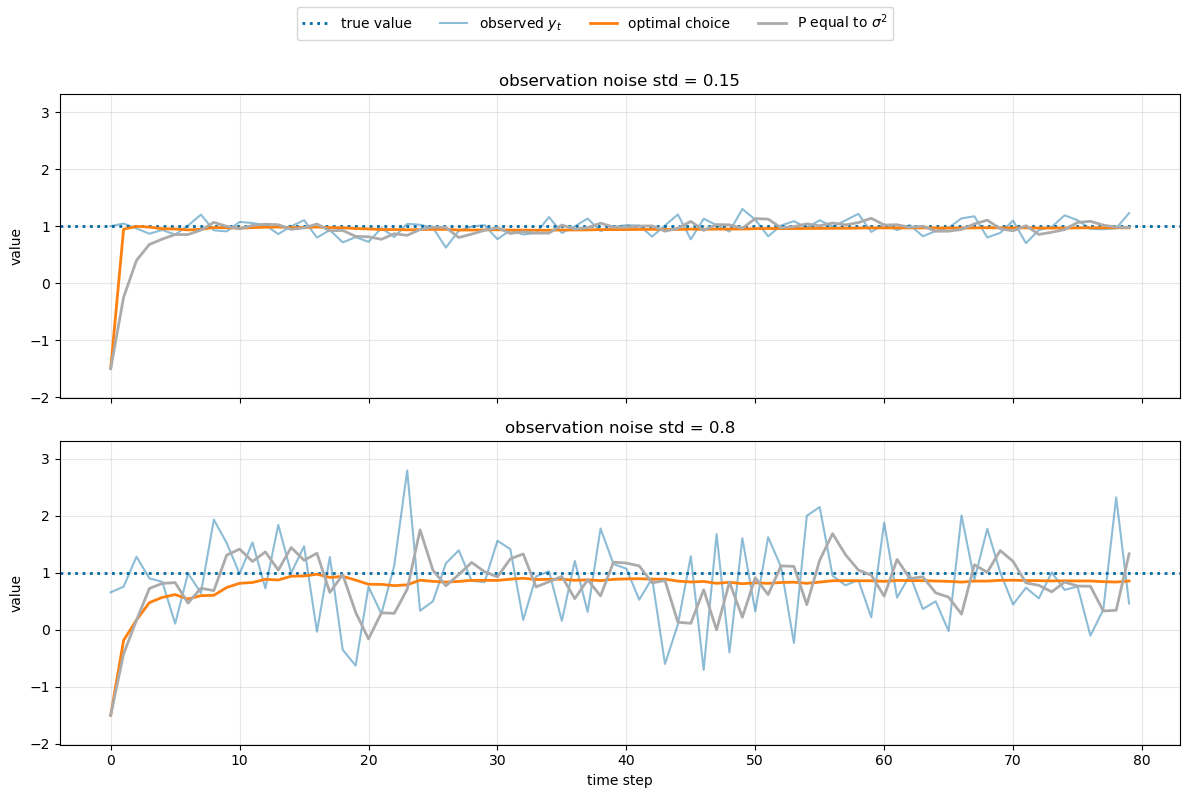

In [ ]:
# Try editing the K_functions dictionary below to see how different choices of K affect the recursive estimation process.
# Each value must be a callable of the form:
#     f(P, sigma) -> scalar K

K_functions = {
    "optimal choice": lambda P, sigma: P / (P + sigma**2),
    "P equal to $\sigma^2$": lambda P, sigma: 0.5,  # This is a common 'mistake' which we'll discuss in the next section.
    # "small constant": lambda P, sigma: 0.08,
    # "large constant": lambda P, sigma: 0.45,
    # "overestimated uncertainty": lambda P, sigma: P / (P + 1),
    # "underestimated uncertainty": lambda P, sigma: P / (P + 0.01),
}

results = run_scalar_recursive_demo(
    K_functions,
    x_true=1.0,
    x0=-1.5,
    T=80,
    noise_stds=(0.15, 0.80),
    P0=1.0,  # a large P0 reflects high initial uncertainty about the true value, which is common in practice.
    seed=7,
)

## A common mistake: which uncertainty belongs to time $t$?

When evaluating a whole trajectory likelihood later, a typical mistake is to use the wrong variance at a given time step.

Start with the question:

> After observing $y_{1:t}$, if we want the uncertainty relevant to time $t$, should we use $\sigma^2$ or $P_t$?

A wrong and a right answer look superficially similar.

### Wrong

From the observation model

$$
y_t = x + w_t, \qquad w_t \sim \mathcal N(0,\sigma^2),
$$

one may incorrectly reason that the uncertainty at time $t$ is just

$$
\mathrm{Var}(y_t \mid x) = \sigma^2.
$$

This is the variance of a new observation conditional on the hidden value. It describes the measurement channel only.

### Right

Our estimate at time $t$ uses observations up to that time, so the relevant uncertainty is the conditional variance of the hidden value given those observations:

$$
P_t = \mathrm{Var}(x \mid y_{1:t}).
$$

In the scalar fixed-$x$ setting, this is equivalently the conditional mean-square estimation error

$$
P_t = \mathbb E\big[(x-\hat x_t)^2 \mid y_{1:t}\big].
$$

So the two quantities are

$$
\sigma^2 = \mathrm{Var}(y_t \mid x),
\qquad
P_t = \mathrm{Var}(x \mid y_{1:t}).
$$

They answer different questions:

- $\sigma^2$: how noisy is one observation if $x$ were known?
- $P_t$: after using data up to time $t$, how uncertain are we about $x$?

This distinction matters for trajectory calculations. If a quantity is about the observation model, $\sigma^2$ is relevant. If it is about the filtered estimate at time $t$, the relevant uncertainty is $P_t$.

### Further reading

One may naturally wonder: as $t$ grows, our later estimates usually become more accurate because they use more observations. Then could we go back and improve earlier estimates as well, now that we have seen additional data?

This is a meaningful question. For time $t$, the filtered uncertainty is

$$
P_t = \mathrm{Var}(x_t \mid y_{1:t}),
$$

while an estimate revised using the full trajectory $y_{1:T}$ would instead involve

$$
\mathrm{Var}(x_t \mid y_{1:T}).
$$

Since $y_{t+1:T}$ contains extra information about $x_t$, it is reasonable that this second quantity can be smaller.

At this point, one might ask another question:

> If using all of $y_{1:T}$ gives a more accurate estimate for each time step, does that also give a better likelihood for the trajectory?

The answer is no, because trajectory likelihood is defined from the data-generating process, not from a hindsight estimate.

For a full observation trajectory, the likelihood is

$$
p(y_{1:T})
=
p(y_1)\,p(y_2 \mid y_1)\cdots p(y_T \mid y_{1:T-1})
=
\prod_{t=1}^T p(y_t \mid y_{1:t-1}),
$$

by the chain rule of conditional probability.

Each factor must only condition on information available before observing $y_t$. That is why the relevant uncertainty at step $t$ is tied to prediction from the past, not to any estimate that also uses future observations.

If we were to replace that with a quantity conditioned on the whole trajectory, we would be implicitly using $y_t$ itself, and even future observations $y_{t+1:T}$, when evaluating the probability of $y_t$. Symbolically, this would correspond to conditioning on the wrong object, such as

$$
p(y_t \mid y_{1:T}),
$$

inside the product. But this is not the factor appearing in the chain rule above, so it does not define the same likelihood.

So there are two different goals:

- improve state estimates by using more data;
- evaluate the probability of the observed trajectory under the model.

The first may use future observations. The second must respect the forward factorization

$$
p(y_{1:T}) = \prod_{t=1}^T p(y_t \mid y_{1:t-1}).
$$

That is why a more accurate hindsight estimate does not imply a different or better likelihood for the trajectory.

# Towards Higher Dimensions

## A useful covariance lemma (You can check this part later)

### Lemma

Let $z$ be a random vector with mean $\mu_z$ and covariance

$$
\mathrm{Cov}(z) = \mathbb E\big[(z-\mu_z)(z-\mu_z)^\top\big].
$$

If

$$
u = Az + b,
$$

where $A$ is a deterministic matrix and $b$ is a deterministic vector, then

$$
\mathrm{Cov}(u) = A\,\mathrm{Cov}(z)\,A^\top.
$$

More generally, if

$$
u = Az + w,
$$

then

$$
\mathrm{Cov}(u)
=
A\,\mathrm{Cov}(z)\,A^\top
+ \mathrm{Cov}(w)
+ A\,\mathrm{Cov}(z,w)
+ \mathrm{Cov}(w,z)\,A^\top.
$$

In particular, if $z$ and $w$ are uncorrelated, then

$$
\mathrm{Cov}(u)
=
A\,\mathrm{Cov}(z)\,A^\top + \mathrm{Cov}(w).
$$

### Proof

From

$$
u = Az + b,
$$

its mean is

$$
\mu_u = \mathbb E[u] = A\mu_z + b.
$$

Therefore

$$
u - \mu_u = A(z-\mu_z).
$$

So

$$
\mathrm{Cov}(u)
=
\mathbb E\big[(u-\mu_u)(u-\mu_u)^\top\big]
=
\mathbb E\big[A(z-\mu_z)(z-\mu_z)^\top A^\top\big].
$$

Since $A$ is deterministic, it can be taken outside the expectation:

$$
\mathrm{Cov}(u)
=
A\,\mathbb E\big[(z-\mu_z)(z-\mu_z)^\top\big]\,A^\top
=
A\,\mathrm{Cov}(z)\,A^\top.
$$

For the more general case

$$
u = Az + w,
$$

write

$$
u - \mu_u = A(z-\mu_z) + (w-\mu_w).
$$

Then

$$
\mathrm{Cov}(u)
=
\mathbb E\Big[
\big(A(z-\mu_z) + (w-\mu_w)\big)
\big(A(z-\mu_z) + (w-\mu_w)\big)^\top
\Big].
$$

Expanding this gives

$$
\mathrm{Cov}(u)
=
A\,\mathrm{Cov}(z)\,A^\top
+ \mathrm{Cov}(w)
+ A\,\mathrm{Cov}(z,w)
+ \mathrm{Cov}(w,z)\,A^\top.
$$

If $z$ and $w$ are uncorrelated, the cross terms vanish.

## Observing high-dimensional data

So far, everything has been scalar. We now move to the vector case, where both the hidden quantity and the observation may have multiple components.

Assume the latent state and observation model

$$
x \in \mathbb R^n,
\qquad
y \in \mathbb R^m,
$$

with

$$
y = Cx + v,
$$

where $C \in \mathbb R^{m\times n}$ is a known observation matrix, and the observation noise satisfies

$$
\mathbb E[v] = 0,
\qquad
\mathrm{Cov}(v) = \Sigma.
$$

Suppose that before seeing the current observation, we already have a prior estimate

$$
\hat x^- = \mathbb E[x \mid \text{past data}],
$$

with prior uncertainty

$$
P^- = \mathrm{Cov}(x \mid \text{past data}).
$$

We now consider an update of the form

$$
\hat x = \hat x^- + K\big(y - C\hat x^-\big),
$$

where $K \in \mathbb R^{n\times m}$ is to be chosen.

The quantity

$$
r = y - C\hat x^-
$$

is the innovation, namely the part of the observation not already explained by the prior estimate.

Our goal is the same as before: choose $K$ so that the updated estimate has minimum mean-square error.

Define the prior estimation error

$$
e^- = x - \hat x^-.
$$

Then, using $y = Cx + v$,

$$
r = y - C\hat x^-
   = Cx + v - C\hat x^-
   = C(x-\hat x^-) + v
   = Ce^- + v.
$$

The updated error is

$$
e = x - \hat x
  = x - \hat x^- - K(y - C\hat x^-)
  = e^- - K(Ce^- + v).
$$

So

$$
e = (I-KC)e^- - Kv.
$$

Assuming $e^-$ and $v$ are uncorrelated, the updated error covariance is (according to the lemma above)

$$
P
=
\mathrm{Cov}(e)
=
(I-KC)P^-(I-KC)^\top + K\Sigma K^\top.
$$

We now choose $K$ to minimize the total updated uncertainty. A standard scalar summary of matrix uncertainty is its trace, so we solve

$$
\min_K \ \mathrm{tr}(P).
$$

Substitute the expression above:

$$
\mathrm{tr}(P)
=
\mathrm{tr}\Big((I-KC)P^-(I-KC)^\top + K\Sigma K^\top\Big).
$$

Expand the first term:

$$
(I-KC)P^-(I-KC)^\top
=
P^- - KCP^- - P^-C^\top K^\top + KCP^-C^\top K^\top.
$$

Hence

$$
\mathrm{tr}(P)
=
\mathrm{tr}(P^-)
- \mathrm{tr}(KCP^-)
- \mathrm{tr}(P^-C^\top K^\top)
+ \mathrm{tr}(KCP^-C^\top K^\top)
+ \mathrm{tr}(K\Sigma K^\top).
$$

Using trace identities, the two middle terms are equal ($P^-$ is symmetric), so

$$
\mathrm{tr}(P)
=
\mathrm{tr}(P^-)
- 2\,\mathrm{tr}(P^-C^\top K^\top)
+ \mathrm{tr}(KCP^-C^\top K^\top)
+ \mathrm{tr}(K\Sigma K^\top).
$$

Differentiate with respect to $K$:

$$
\frac{\partial}{\partial K}\mathrm{tr}(P)
=
0
-2P^-C^\top
+
2K(CP^-C^\top)
+
2K\Sigma.
$$

Set the derivative to zero:

$$
-2P^-C^\top + 2K(CP^-C^\top) + 2K\Sigma = 0.
$$

Therefore,

$$
K(CP^-C^\top + \Sigma) = P^-C^\top,
$$

and the optimal update matrix is

$$
K = P^-C^\top (CP^-C^\top + \Sigma)^{-1}.
$$

This is the higher-dimensional analogue of the scalar formula.

The matrix

$$
S = CP^-C^\top + \Sigma
$$

is the covariance of the innovation $r = y - C\hat x^-$, since

$$
\mathrm{Cov}(r)
=
\mathrm{Cov}(Ce^- + v)
=
CP^-C^\top + \Sigma.
$$

So the update can also be written as

$$
\hat x = \hat x^- + P^-C^\top S^{-1}(y - C\hat x^-).
$$

This has the same logic as in the scalar case:

- if the prior uncertainty $P^-$ is large, the estimate should react more strongly to the new observation;
- if the observation noise covariance $\Sigma$ is large, the estimate should react more cautiously.

The only difference is that uncertainty is now distributed across multiple directions, so the update strength becomes a matrix rather than a scalar.

## When the system evolve

In the previous part, the hidden quantity was treated as fixed while repeated observations arrived. We now move to the case where the hidden state itself changes with time.

Assume the latent state evolves according to

$$
x_t = A x_{t-1} + B u_t + w_t,
$$

and the observation is

$$
y_t = C x_t + v_t.
$$

Here:

- $x_t$ is the latent state at time $t$;
- $u_t$ is a known input;
- $y_t$ is the observation at time $t$;
- $w_t$ is process noise with
  $$
  \mathbb E[w_t] = 0,
  \qquad
  \mathrm{Cov}(w_t) = Q;
  $$
- $v_t$ is observation noise with
  $$
  \mathbb E[v_t] = 0,
  \qquad
  \mathrm{Cov}(v_t) = \Sigma.
  $$

We now need two versions of the estimate.

### Predicted state

Before seeing $y_t$, we form a prediction using only information up to time $t-1$:

$$
\hat x_t^- = \mathbb E[x_t \mid y_{1:t-1}].
$$

Its uncertainty is

$$
P_t^- = \mathrm{Cov}(x_t \mid y_{1:t-1}).
$$

### Updated state

After seeing $y_t$, we update the estimate to

$$
\hat x_t = \mathbb E[x_t \mid y_{1:t}],
$$

with uncertainty

$$
P_t = \mathrm{Cov}(x_t \mid y_{1:t}).
$$

So:

- $\hat x_t^-$ and $P_t^-$ are the prediction before the new observation;
- $\hat x_t$ and $P_t$ are the update after using the new observation.

### State prediction equation

From the system model

$$
x_t = A x_{t-1} + B u_t + w_t,
$$

take conditional expectation given $y_{1:t-1}$:

$$
\hat x_t^-
=
\mathbb E[x_t \mid y_{1:t-1}]
=
\mathbb E[A x_{t-1} + B u_t + w_t \mid y_{1:t-1}].
$$

Using linearity of expectation, and the facts that $u_t$ is known and $\mathbb E[w_t]=0$,

$$
\hat x_t^- = A \hat x_{t-1} + B u_t.
$$

This is the state prediction rule.

### Covariance prediction equation

Define the prediction error

$$
e_t^- = x_t - \hat x_t^-.
$$

Substitute the system equation and the prediction formula:

$$
e_t^-
=
(A x_{t-1} + B u_t + w_t) - (A \hat x_{t-1} + B u_t)
=
A(x_{t-1} - \hat x_{t-1}) + w_t.
$$

Now take covariance on both sides. Using the covariance lemma from before, and assuming $(x_{t-1} - \hat x_{t-1})$ is uncorrelated with $w_t$,

$$
P_t^-
=
\mathrm{Cov}(e_t^-)
=
A\,\mathrm{Cov}(x_{t-1} - \hat x_{t-1})\,A^\top + \mathrm{Cov}(w_t).
$$

Since

$$
\mathrm{Cov}(x_{t-1} - \hat x_{t-1}) = P_{t-1},
\qquad
\mathrm{Cov}(w_t) = Q,
$$

we obtain

$$
P_t^- = A P_{t-1} A^\top + Q.
$$

This is the covariance prediction rule.

### Summary of the prediction step

When the latent system evolves, the estimate and its uncertainty are propagated forward by

$$
\hat x_t^- = A \hat x_{t-1} + B u_t,
$$

and

$$
P_t^- = A P_{t-1} A^\top + Q.
$$

The first equation predicts the state, and the second propagates the uncertainty.

After this prediction step, the new observation $y_t$ can be used to update both quantities again.

## What if it's nonlinear? (Advanced reading)

The evolution model above is linear in the latent state. A natural next step is to allow nonlinear state evolution and nonlinear observation, while still keeping the same probabilistic viewpoint.

Instead of

$$
x_t = A x_{t-1} + B u_t + w_t,
\qquad
y_t = C x_t + v_t,
$$

consider the more general model

$$
x_t = f(x_{t-1}, u_t) + w_t,
\qquad
y_t = h(x_t) + v_t,
$$

where

- $f$ is a nonlinear state-transition function;
- $h$ is a nonlinear observation function;
- $w_t$ is process noise with
  $$
  \mathbb E[w_t] = 0,
  \qquad
  \mathrm{Cov}(w_t) = Q;
  $$
- $v_t$ is observation noise with
  $$
  \mathbb E[v_t] = 0,
  \qquad
  \mathrm{Cov}(v_t) = \Sigma.
  $$

The filtered quantities are still defined in the same way:

$$
\hat x_t^- = \mathbb E[x_t \mid y_{1:t-1}],
\qquad
P_t^- = \mathrm{Cov}(x_t \mid y_{1:t-1}),
$$

and

$$
\hat x_t = \mathbb E[x_t \mid y_{1:t}],
\qquad
P_t = \mathrm{Cov}(x_t \mid y_{1:t}).
$$

What changes is that, in general,

$$
\mathbb E[f(x_{t-1}, u_t) \mid y_{1:t-1}]
\neq
f(\mathbb E[x_{t-1} \mid y_{1:t-1}], u_t),
$$

and similarly,

$$
\mathbb E[h(x_t) \mid y_{1:t-1}]
\neq
h(\mathbb E[x_t \mid y_{1:t-1}]).
$$

So in the nonlinear case, we can no longer propagate mean and covariance exactly using only matrix formulas such as

$$
\hat x_t^- = A \hat x_{t-1} + B u_t,
\qquad
P_t^- = A P_{t-1} A^\top + Q.
$$

The central idea is to approximate how a probability distribution changes under a nonlinear map.

A naive approach would be Monte Carlo:

1. sample many points from the current state distribution;
2. pass every sample through the nonlinear function;
3. compute the empirical mean and covariance of the transformed cloud.

For example, if

$$
x_{t-1} \mid y_{1:t-1} \approx \mathcal N(\hat x_{t-1}, P_{t-1}),
$$

then one could draw many samples

$$
x_{t-1}^{(1)}, \dots, x_{t-1}^{(N)},
$$

propagate them through the nonlinear transition

$$
x_t^{(i)} = f(x_{t-1}^{(i)}, u_t),
$$

and estimate the transformed mean and covariance from the resulting point cloud.

This idea is conceptually simple and often accurate when the number of samples is large. However, it may be computationally expensive, noisy from run to run, and inconvenient when filtering must be performed repeatedly online.

The next idea is therefore:

> instead of using many random samples, use a small deterministic set of representative points chosen to capture the main geometry of the current distribution.

These representative points are selected so that their weighted mean and covariance match the mean and covariance of the current belief. They are then pushed through the nonlinear map, and the transformed mean and covariance are reconstructed from the transformed points.

So the method keeps the spirit of Monte Carlo, but replaces random sampling by a carefully designed deterministic sampling rule.

For a state of dimension $n$, the method uses $2n+1$ such points. They are arranged around the current mean:

- one point at the center;
- one positive and one negative point along each principal spread direction of the covariance.

If the current belief is

$$
x_{t-1} \mid y_{1:t-1} \approx \mathcal N(\hat x_{t-1}, P_{t-1}),
$$

then the covariance matrix $P_{t-1}$ determines both the orientation and the scale of this point set. The points are chosen so that they reflect the local spread of uncertainty encoded by $P_{t-1}$.

This gives the following intuition:

- the mean tells us where the cloud is centered;
- the covariance tells us how uncertainty is spread in different directions;
- the deterministic point set probes the nonlinear function along those directions.

After these points are transformed by the nonlinear map, the output cloud carries information about how the nonlinearity bends, stretches, or rotates the uncertainty region. The transformed mean and covariance are then approximated from that output cloud.

This is the main idea of the method:

> represent the current uncertainty by a small structured cloud of deterministic points, propagate that cloud through the nonlinear function, and recover the new mean and covariance from the transformed cloud.

In that sense, the method is neither exact nonlinear Bayesian inference nor ordinary random Monte Carlo. It is a deterministic moment-propagation method designed to approximate how the first two moments of a distribution evolve under nonlinear transformations.

The following code gives an illustration of this idea, and the algorithmic details can be read directly from the implementation for those interested, since the construction is now fairly standard.

In [41]:
# Don't Edit (Unless You've Finished the Whole Notebook and Understand the Content Well)

import warnings
from collections.abc import Callable

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse


def _validate_mean_and_cov(x, P):
    x = np.asarray(x, dtype=float)
    P = np.asarray(P, dtype=float)

    if x.shape != (2,):
        raise ValueError(f"x must have shape (2,), got {x.shape}.")
    if P.shape != (2, 2):
        raise ValueError(f"P must have shape (2, 2), got {P.shape}.")
    if not np.allclose(P, P.T, atol=1e-10):
        warnings.warn("P is not exactly symmetric; symmetrizing it.", stacklevel=2)
        P = 0.5 * (P + P.T)

    eigvals = np.linalg.eigvalsh(P)
    if np.min(eigvals) < -1e-10:
        raise ValueError("P must be positive semidefinite.")
    return x, P


def _validate_transform_output(name, z, out):
    out = np.asarray(out, dtype=float)
    if out.shape != (2,):
        raise ValueError(
            f"Transform '{name}' must return shape (2,), got {out.shape} for input {z}."
        )
    if not np.all(np.isfinite(out)):
        raise ValueError(f"Transform '{name}' returned non-finite values for input {z}.")
    return out


def _ukf_sigma_points(x, P, alpha=1e-3, beta=2.0, spread_ratio=0.75):
    n = x.shape[0]

    ## Standard parameterization:
    # lam = alpha**2 * (n + kappa) - n
    # scale = n + lam

    ## Personally, for a more transparent geometric interpretation, I use 
    # `spread_ratio` 
    # to control how wide the sigma-point cloud is, and I recommend this method.  --Qingyun
    scale = n * spread_ratio
    lam = scale - n

    if scale <= 0:
        raise ValueError(
            f"Invalid UKF parameters: n + lambda = {scale} must be positive."
        )

    try:
        L = np.linalg.cholesky(scale * P)
    except np.linalg.LinAlgError:
        jitter = 1e-9 * np.eye(n)
        L = np.linalg.cholesky(scale * (P + jitter))

    sigma_pts = [x]
    for i in range(n):
        sigma_pts.append(x + L[:, i])
        sigma_pts.append(x - L[:, i])
    sigma_pts = np.asarray(sigma_pts)

    Wm = np.full(2 * n + 1, 1.0 / (2.0 * scale))
    Wc = np.full(2 * n + 1, 1.0 / (2.0 * scale))
    Wm[0] = lam / scale
    Wc[0] = lam / scale + (1.0 - alpha**2 + beta)
    print(sigma_pts.shape)
    return sigma_pts, Wm, Wc


def _weighted_mean_and_cov(points, Wm, Wc):
    mean = np.sum(Wm[:, None] * points, axis=0)
    diffs = points - mean
    cov = np.zeros((2, 2), dtype=float)
    for i in range(points.shape[0]):
        cov += Wc[i] * np.outer(diffs[i], diffs[i])
    cov = 0.5 * (cov + cov.T)
    return mean, cov


def _cov_ellipse_params(cov, n_std=2.0):
    eigvals, eigvecs = np.linalg.eigh(cov)
    eigvals = np.maximum(eigvals, 0.0)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    width = 2.0 * n_std * np.sqrt(eigvals[0])
    height = 2.0 * n_std * np.sqrt(eigvals[1])
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    return width, height, angle


def _add_cov_ellipse(ax, mean, cov, n_std=2.0, face_alpha=0.16, edge_alpha=0.55, label=None):
    width, height, angle = _cov_ellipse_params(cov, n_std=n_std)
    ell_fill = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        fill=True,
        alpha=face_alpha,
        linewidth=0,
        label=label,
    )
    ell_edge = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        fill=False,
        alpha=edge_alpha,
        linewidth=2,
    )
    ax.add_patch(ell_fill)
    ax.add_patch(ell_edge)


def _evaluate_transform_on_points(name, func, points, P):
    outputs = []
    for z in points:
        out = func(np.asarray(z, dtype=float), P)
        outputs.append(_validate_transform_output(name, z, out))
    return np.asarray(outputs)


def plot_ukf_illustrations(
    f_dict: dict[str, Callable],
    x,
    P,
    *,
    n_random=100,
    seed=7,
    alpha=1e-3,
    beta=2.0,
    spread_ratio=0.75,
    grid_points=29,
    pad_ratio=0.12,
    figsize=(15, 8),
):
    """
    For each transform in f_dict, draw a 3x2 figure:

    row 0: local displacement field / blank panel
    row 1: random Gaussian sampling before / after transform
    row 2: deterministic UKF sigma points before / after transform

    Each callable must have signature:
        f(z, P) -> array_like shape (2,)
    """
    if not isinstance(f_dict, dict) or len(f_dict) == 0:
        raise ValueError("f_dict must be a non-empty dict of name -> callable.")
    x, P = _validate_mean_and_cov(x, P)

    for name, func in f_dict.items():
        if not callable(func):
            raise TypeError(f"Item '{name}' is not callable.")

    rng = np.random.default_rng(seed)

    for name, func in f_dict.items():
        # random sampling
        rand_before = rng.multivariate_normal(mean=x, cov=P, size=n_random)
        rand_after = _evaluate_transform_on_points(name, func, rand_before, P)

        # deterministic sigma points
        sigma_before, Wm, Wc = _ukf_sigma_points(x, P, alpha=alpha, beta=beta, spread_ratio=spread_ratio)
        sigma_after = _evaluate_transform_on_points(name, func, sigma_before, P)

        # transformed sigma-point mean/cov for ellipse
        sigma_after_mean, sigma_after_cov = _weighted_mean_and_cov(sigma_after, Wm, Wc)

        # choose shared limits from before/after samples
        all_pts = np.vstack([rand_before, rand_after, sigma_before, sigma_after, x[None, :], sigma_after_mean[None, :]])
        mins = all_pts.min(axis=0)
        maxs = all_pts.max(axis=0)
        span = np.maximum(maxs - mins, 1e-6)
        mins = mins - pad_ratio * span
        maxs = maxs + pad_ratio * span
        xlim = (mins[0], maxs[0])
        ylim = (mins[1], maxs[1])

        fig, axes = plt.subplots(2, 3, figsize=figsize, sharex=True, sharey=True)

        # ---- row 0, col 0: local displacement field ----
        ax = axes[0, 0]
        gx = np.linspace(xlim[0], xlim[1], grid_points)
        gy = np.linspace(ylim[0], ylim[1], grid_points)
        X, Y = np.meshgrid(gx, gy)

        U = np.zeros_like(X, dtype=float)
        V = np.zeros_like(Y, dtype=float)
        for i in range(X.shape[0]):
            for j in range(X.shape[1]):
                z = np.array([X[i, j], Y[i, j]], dtype=float)
                z_next = _validate_transform_output(name, z, func(z, P))
                disp = z_next - z
                U[i, j] = disp[0]
                V[i, j] = disp[1]

        speed = np.sqrt(U**2 + V**2)
        lw = 0.6 + 1.8 * speed / (np.max(speed) + 1e-12)
        ax.streamplot(X, Y, U, V, density=1.0, linewidth=lw, arrowsize=1.0)
        _add_cov_ellipse(ax, x, P, n_std=2.0, label=r"$P^-$")
        ax.legend(loc="lower right")
        ax.set_title("local displacement field")
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.25)

        # ---- row 0, col 1: random Gaussian samples before ----
        ax = axes[0, 1]
        ax.scatter(rand_before[:, 0], rand_before[:, 1], s=18, alpha=0.6)
        ax.scatter([x[0]], [x[1]], s=60, marker="x", linewidths=2)
        _add_cov_ellipse(ax, x, P, n_std=2.0, label=r"$P^-$")
        ax.legend(loc="lower right")
        ax.set_title("random Gaussian samples")
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.25)

        # ---- row 0, col 2: random Gaussian samples after ----
        ax = axes[1, 1]
        rand_after_mean = rand_after.mean(axis=0)
        rand_after_cov = np.cov(rand_after.T, bias=False)
        ax.scatter(rand_after[:, 0], rand_after[:, 1], s=18, alpha=0.6)
        ax.scatter([rand_after_mean[0]], [rand_after_mean[1]], s=60, marker="x", linewidths=2)
        _add_cov_ellipse(ax, rand_after_mean, rand_after_cov, n_std=2.0, label=r"$P_{statistic}$")
        ax.legend(loc="lower right")
        ax.set_title("random samples after transform")
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.25)

        # ---- row 1, col 0: blank ----
        axes[1, 0].axis("off")
        axes[1, 0].set_title("")

        # ---- row 1, col 1: deterministic UKF samples before ----
        ax = axes[0, 2]
        ax.scatter(sigma_before[:, 0], sigma_before[:, 1], s=60)
        ax.scatter([x[0]], [x[1]], s=70, marker="x", linewidths=2)
        _add_cov_ellipse(ax, x, P, n_std=2.0, label=r"$P^-$")
        ax.legend(loc="lower right")
        ax.set_title("deterministic sigma points")
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.25)

        # ---- row 1, col 2: deterministic UKF samples after ----
        ax = axes[1, 2]
        ax.scatter(sigma_after[:, 0], sigma_after[:, 1], s=60)
        ax.scatter([sigma_after_mean[0]], [sigma_after_mean[1]], s=70, marker="x", linewidths=2)
        _add_cov_ellipse(ax, sigma_after_mean, sigma_after_cov, n_std=2.0, label=r"$P_{pred}$")
        ax.legend(loc="lower right")
        ax.set_title("sigma points after transform")
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.25)

        # shared limits and labels
        for ax in axes.ravel():
            if ax.axison:
                ax.set_xlim(*xlim)
                ax.set_ylim(*ylim)

        axes[1, 1].set_xlabel("$x_1$")
        axes[1, 2].set_xlabel("$x_1$")
        axes[0, 0].set_ylabel("$x_2$")
        axes[1, 1].set_ylabel("$x_2$")

        fig.suptitle(name, fontsize=14)
        fig.tight_layout()
        plt.show()

(5, 2)


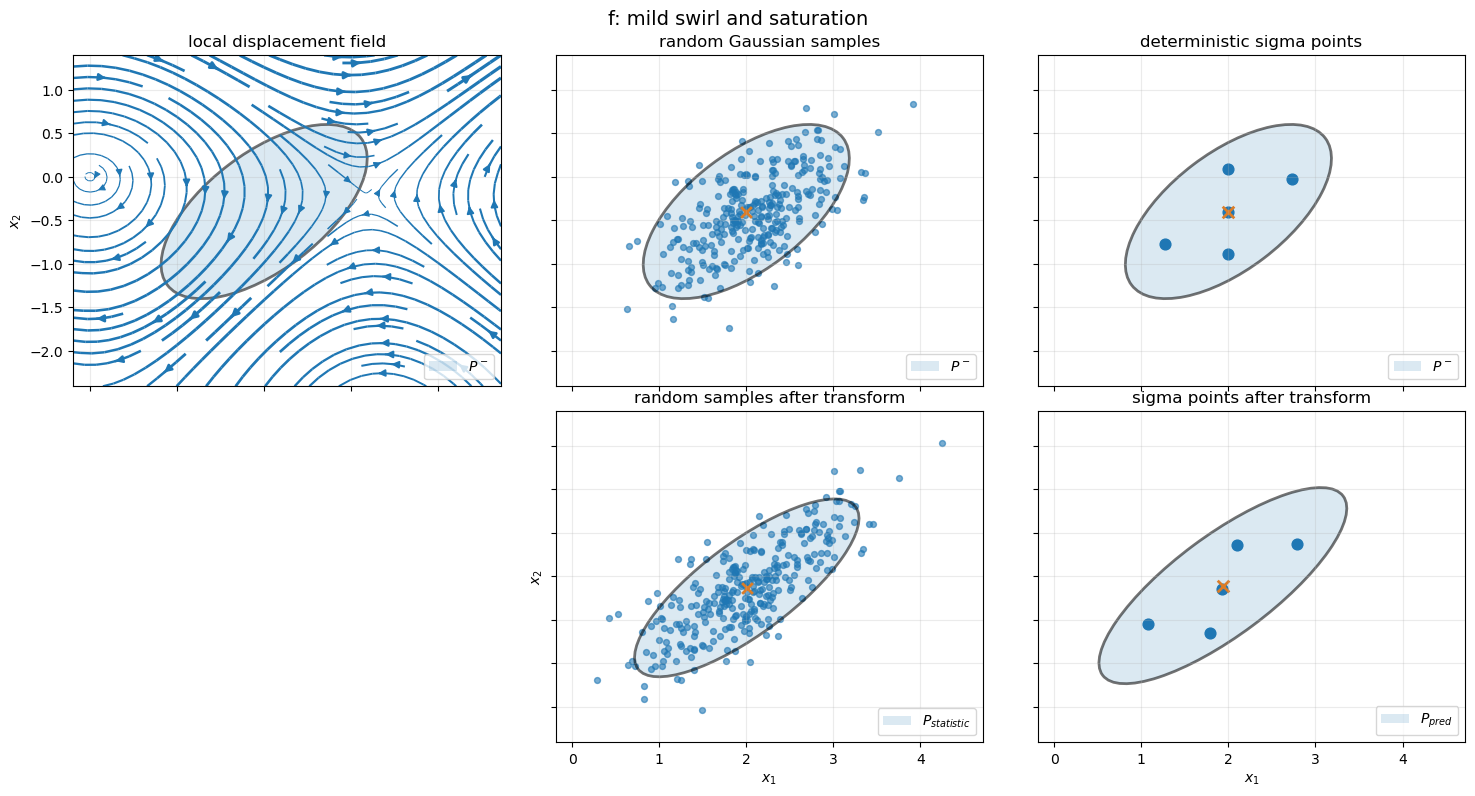

In [ ]:
# Each callable must have signature:
#     f(z) -> array_like with shape (2,)
# where z is a point in R^2.

f_dict = {
    "f: mild swirl and saturation": lambda z: np.array([
        z[0] + 0.35 * np.sin(z[1]) + 0.08 * z[0]**2 / (1.0 + z[0]**2 + z[1]**2),
        z[1] - 0.25 * np.sin(z[0]) + 0.12 * z[0] * z[1] / (1.0 + z[0]**2 + z[1]**2),
    ]),
    # "another map": lambda z, P: ...,
}

x = np.array([2.0, -0.4])
P = np.array([
    [0.35, 0.18],
    [0.18, 0.25],
])

plot_ukf_illustrations(
    f_dict,
    x,
    P,
    n_random=300,
    seed=7,
    alpha=1e-3,
    beta=2.0,
    spread_ratio=0.75,
    grid_points=29,
)

# Let's try it!

In [ ]:
# Please implement the data synthesizer - LinearModelGenerator class below according to the specifications in the docstrings.

from __future__ import annotations

from typing import Optional
import numpy as np

vector = np.ndarray
matrix = np.ndarray


class LinearModelGenerator:
    __slots__ = (
        "A",
        "B",
        "C",
        "Q",
        "R",
        "x0",
        "x",
        "latent_trajectory",
        "rng",
    )

    def __init__(
        self,
        A: matrix,
        B: matrix,
        C: matrix,
        Q: matrix,
        R: matrix,
        x0: vector,
        *,
        random_seed: Optional[int] = None,
    ) -> None:
        """
        Create a linear latent-state data generator.

        Latent dynamics:
            x_t = A x_{t-1} + B u_t + w_t
            w_t ~ N(0, Q)

        Observation model:
            y_t = C x_t + v_t
            v_t ~ N(0, R)

        Parameters
        ----------
        A : matrix, shape (n, n)
            State transition matrix.
        B : matrix, shape (n, m)
            Input-to-state matrix. Use shape (n, 0) if there is no input channel.
        C : matrix, shape (p, n)
            State-to-observation matrix.
        Q : matrix, shape (n, n)
            Process-noise covariance.
        R : matrix, shape (p, p)
            Observation-noise covariance.
        x0 : vector, shape (n,)
            Initial latent state used by `reset()`.
        random_seed : int | None
            Random seed for reproducible sampling.

        Attributes to maintain
        ----------------------
        self.A, self.B, self.C, self.Q, self.R : matrix
            Model parameters copied from the constructor.
        self.x0 : vector
            Initial latent state.
        self.x : vector
            Current latent state.
        self.latent_trajectory : list[vector]
            History of true latent states. It should be externally accessible, and
            `reset()` should clear and reinitialize it.
        self.rng : np.random.Generator
            Random number generator.

        Expected dimension checks
        -------------------------
        Let
            n = A.shape[0]   # latent dimension
            m = B.shape[1]   # input dimension
            p = C.shape[0]   # observation dimension

        Check at least the following:
            A.shape == (n, n)
            B.shape == (n, m)
            C.shape == (p, n)
            Q.shape == (n, n)
            R.shape == (p, p)
            x0.shape == (n,)

        It is also sensible to check:
            Q and R are symmetric
            Q and R are positive semidefinite
        """
        pass

    @staticmethod
    def one_step_latent(
        x: vector,
        u: Optional[vector],
        A: matrix,
        B: matrix,
        Q: matrix,
        reset: Optional[vector] = None,
    ) -> vector:
        """
        Generate one latent-state step from the linear dynamical model.

        Model
        -----
        If `reset` is None:
            x_next = A x + B u + w
            w ~ N(0, Q)

        If `reset` is not None:
            use `reset` as the state being advanced instead of `x`.
            This is useful when one wants to restart from a supplied state
            without changing the class-wide stored initial state.

        Parameters
        ----------
        x : vector, shape (n,)
            Current latent state.
        u : vector | None, shape (m,)
            Input at the current step. If there is no input, either pass None
            and interpret it as a zero vector, or require the caller to pass a
            zero vector explicitly.
        A : matrix, shape (n, n)
            State transition matrix.
        B : matrix, shape (n, m)
            Input-to-state matrix.
        Q : matrix, shape (n, n)
            Process-noise covariance.
        reset : vector | None, shape (n,)
            Optional replacement state to advance from.

        Returns
        -------
        x_next : vector, shape (n,)
            The next true latent state after one transition step.

        Notes for implementation
        ------------------------
        - Validate dimensions of x, u, A, B, Q, and reset.
        - Draw process noise from a zero-mean Gaussian with covariance Q.
        - If u is None, use a zero vector of shape (m,).
        - This method is declared static because its behavior depends only on
          the provided arguments; it need not read object state directly.
        """
        pass

    @staticmethod
    def one_step_observation(
        x: vector,
        C: matrix,
        R: matrix,
    ) -> vector:
        """
        Generate one observation from the linear observation model.

        Model
        -----
            y = C x + v
            v ~ N(0, R)

        Parameters
        ----------
        x : vector, shape (n,)
            Current true latent state.
        C : matrix, shape (p, n)
            Observation matrix.
        R : matrix, shape (p, p)
            Observation-noise covariance.

        Returns
        -------
        y : vector, shape (p,)
            Noisy observation generated from the latent state.

        Notes for implementation
        ------------------------
        - Validate dimensions of x, C, and R.
        - Draw observation noise from a zero-mean Gaussian with covariance R.
        - This method is declared static because it is a pure model operation
          determined by its arguments.
        """
        pass

    def observe(self, u: Optional[vector] = None) -> vector:
        """
        Advance the latent state by one step and return the corresponding observation.

        Intended behavior
        -----------------
        1. Use the current latent state `self.x`.
        2. Advance it by one latent transition using `one_step_latent(...)`.
        3. Store the new true latent state in `self.latent_trajectory`.
        4. Generate and return an observation using `one_step_observation(...)`.

        Parameters
        ----------
        u : vector | None, shape (m,)
            Optional input at the current step. If None, treat it as zero input.

        Returns
        -------
        y : vector, shape (p,)
            Observation corresponding to the newly updated latent state.

        Side effects
        ------------
        - Updates `self.x`.
        - Appends a copy of the new latent state to `self.latent_trajectory`.

        Useful convention
        -----------------
        On initialization or after `reset()`, `self.latent_trajectory` may either:
        - start with the initial state already stored, or
        - start empty and only store states after the first transition.
        Choose one convention and keep it consistent.
        """
        pass

    def reset(self) -> None:
        """
        Reset the generator to its initial latent state.

        Intended behavior
        -----------------
        - Set `self.x` back to `self.x0` (usually as a copy).
        - Clear `self.latent_trajectory`.
        - Optionally reinsert the initial state into `self.latent_trajectory`
          if that is the convention chosen for this class.

        Returns
        -------
        None

        Purpose
        -------
        This allows repeated simulations from the same initial condition and
        ensures that previously stored true latent trajectories can be discarded.
        """
        pass

In [ ]:
# Please implement the linear filtering class - LinearFilter - below according to the specifications in the docstrings.

from __future__ import annotations

from typing import Optional
import numpy as np

vector = np.ndarray
matrix = np.ndarray


class LinearFilter:
    __slots__ = (
        "generator",
        "A",
        "B",
        "C",
        "Q",
        "R",
        "x_hat0",
        "P0",
        "filtered_trajectory",
        "_predicted_trajectory",
        "_predicted_cov_trajectory",
        "_filtered_cov_trajectory",
    )

    def __init__(
        self,
        generator: LinearModelGenerator,
        A: matrix,
        B: matrix,
        C: matrix,
        Q: matrix,
        R: matrix,
        x_hat0: vector,
        P0: matrix,
    ) -> None:
        """
        Create a linear filtering object driven by an existing data generator.

        State-space model assumed by the filter
        --------------------------------------
            x_t = A x_{t-1} + B u_t + w_t
            y_t = C x_t + v_t

            w_t ~ N(0, Q)
            v_t ~ N(0, R)

        Parameters
        ----------
        generator : LinearModelGenerator
            Existing generator object that produces observations. This class does
            not create the generator internally; it only uses the passed object.
        A : matrix, shape (n, n)
            State transition matrix used by the filter.
        B : matrix, shape (n, m)
            Input-to-state matrix used by the filter.
        C : matrix, shape (p, n)
            Observation matrix used by the filter.
        Q : matrix, shape (n, n)
            Process-noise covariance used by the filter.
        R : matrix, shape (p, p)
            Observation-noise covariance used by the filter.
        x_hat0 : vector, shape (n,)
            Initial filtered state estimate.
        P0 : matrix, shape (n, n)
            Initial filtered covariance.

        Stored members
        --------------
        generator : LinearModelGenerator
            The external generator used to produce observations.
        A, B, C, Q, R : matrix
            Filter parameters.
        x_hat0 : vector
            Initial filtered estimate.
        P0 : matrix
            Initial filtered covariance.

        filtered_trajectory : list[vector]
            Publicly accessible history of filtered state estimates.

        _predicted_trajectory : list[vector]
            Internal history of predicted state estimates.
        _predicted_cov_trajectory : list[matrix]
            Internal history of predicted covariances.
        _filtered_cov_trajectory : list[matrix]
            Internal history of filtered covariances.

        Notes
        -----
        - Intermediate quantities such as the gain or innovation covariance
          should not be stored as members.
        - Single-step temporary values should remain local variables inside
          methods such as `observe_and_filter(...)`.
        - The trajectory lists store copies over time; do not rely on one
          mutable array being reused.
        """
        if not isinstance(generator, LinearModelGenerator):
            raise TypeError("generator must be a LinearModelGenerator object.")

        A = np.asarray(A, dtype=float)
        B = np.asarray(B, dtype=float)
        C = np.asarray(C, dtype=float)
        Q = np.asarray(Q, dtype=float)
        R = np.asarray(R, dtype=float)
        x_hat0 = np.asarray(x_hat0, dtype=float)
        P0 = np.asarray(P0, dtype=float)

        n = A.shape[0]
        if A.shape != (n, n):
            raise ValueError(f"A must have shape ({n}, {n}), got {A.shape}.")
        if x_hat0.shape != (n,):
            raise ValueError(f"x_hat0 must have shape ({n},), got {x_hat0.shape}.")
        if P0.shape != (n, n):
            raise ValueError(f"P0 must have shape ({n}, {n}), got {P0.shape}.")
        if Q.shape != (n, n):
            raise ValueError(f"Q must have shape ({n}, {n}), got {Q.shape}.")
        if B.ndim != 2 or B.shape[0] != n:
            raise ValueError(f"B must have shape ({n}, m), got {B.shape}.")
        p = C.shape[0]
        if C.ndim != 2 or C.shape[1] != n:
            raise ValueError(f"C must have shape (p, {n}), got {C.shape}.")
        if R.shape != (p, p):
            raise ValueError(f"R must have shape ({p}, {p}), got {R.shape}.")

        self.generator = generator
        self.A = A.copy()
        self.B = B.copy()
        self.C = C.copy()
        self.Q = Q.copy()
        self.R = R.copy()
        self.x_hat0 = x_hat0.copy()
        self.P0 = P0.copy()

        self.filtered_trajectory: list[vector] = [self.x_hat0.copy()]
        self._predicted_trajectory: list[vector] = []
        self._predicted_cov_trajectory: list[matrix] = []
        self._filtered_cov_trajectory: list[matrix] = [self.P0.copy()]

    @staticmethod
    def predict(
        x_hat: vector,
        P: matrix,
        u: Optional[vector],
        A: matrix,
        B: matrix,
        Q: matrix,
    ) -> tuple[vector, matrix]:
        """
        Compute one prediction step of the linear filter.

        Expected model
        --------------
            x_t = A x_{t-1} + B u_t + w_t
            w_t ~ N(0, Q)

        Inputs
        ------
        x_hat : vector, shape (n,)
            Previous filtered state estimate.
        P : matrix, shape (n, n)
            Previous filtered covariance.
        u : vector | None, shape (m,)
            Input at the current time step. If None, treat it as zero input.
        A : matrix, shape (n, n)
            State transition matrix.
        B : matrix, shape (n, m)
            Input-to-state matrix.
        Q : matrix, shape (n, n)
            Process-noise covariance.

        Returns
        -------
        x_hat_pred : vector, shape (n,)
            Predicted state estimate before seeing the new observation.
        P_pred : matrix, shape (n, n)
            Predicted covariance before seeing the new observation.

        Students should implement
        -------------------------
            x_hat_pred = A @ x_hat + B @ u
            P_pred = A @ P @ A.T + Q

        with the convention that if u is None, it is replaced by a zero vector
        of shape (m,).
        """
        pass

    @staticmethod
    def update(
        x_hat_pred: vector,
        P_pred: matrix,
        y: vector,
        C: matrix,
        R: matrix,
    ) -> tuple[vector, matrix]:
        """
        Compute one update step of the linear filter.

        Observation model
        -----------------
            y_t = C x_t + v_t
            v_t ~ N(0, R)

        Inputs
        ------
        x_hat_pred : vector, shape (n,)
            Predicted state estimate before using the new observation.
        P_pred : matrix, shape (n, n)
            Predicted covariance before using the new observation.
        y : vector, shape (p,)
            New observation.
        C : matrix, shape (p, n)
            Observation matrix.
        R : matrix, shape (p, p)
            Observation-noise covariance.

        Returns
        -------
        x_hat_filt : vector, shape (n,)
            Filtered state estimate after using the new observation.
        P_filt : matrix, shape (n, n)
            Filtered covariance after using the new observation.

        Students should implement
        -------------------------
            S = C @ P_pred @ C.T + R
            K = P_pred @ C.T @ inv(S)
            x_hat_filt = x_hat_pred + K @ (y - C @ x_hat_pred)
            P_filt = (I - K @ C) @ P_pred

        or an algebraically equivalent numerically stable form.
        Intermediate variables such as K and S should remain local variables and
        should not be stored as members of the class.
        """
        pass

    def reset(self) -> None:
        """
        Reset both the generator and the filter histories.

        Effect
        ------
        - Reset the generator to its own initial latent state.
        - Reset the filtered trajectory to contain only x_hat0.
        - Clear predicted histories.
        - Reset filtered covariance history to contain only P0.
        """
        self.generator.reset()
        self.filtered_trajectory = [self.x_hat0.copy()]
        self._predicted_trajectory = []
        self._predicted_cov_trajectory = []
        self._filtered_cov_trajectory = [self.P0.copy()]

    def _normalize_inputs(self, t: int, u: Optional[vector | matrix]) -> list[Optional[vector]]:
        """
        Convert the user input specification into a list of length t.

        Accepted forms
        --------------
        u is None:
            interpreted as zero input for all time steps.

        u is a vector of shape (m,):
            the same input is reused for all t steps.

        u is a matrix of shape (t, m):
            row i is the input used at step i.

        Returns
        -------
        inputs : list[vector | None]
            Length-t list of per-step inputs.

        Raises
        ------
        ValueError
            If the provided input does not have a shape compatible with t and B.
        """
        if t <= 0:
            raise ValueError("t must be a positive integer.")

        m = self.B.shape[1]

        if u is None:
            return [None] * t

        arr = np.asarray(u, dtype=float)

        if arr.ndim == 1:
            if arr.shape != (m,):
                raise ValueError(
                    f"Single-step input must have shape ({m},), got {arr.shape}."
                )
            return [arr.copy() for _ in range(t)]

        if arr.ndim == 2:
            if arr.shape != (t, m):
                raise ValueError(
                    f"Time-varying input must have shape ({t}, {m}), got {arr.shape}."
                )
            return [arr[i].copy() for i in range(t)]

        raise ValueError("u must be None, a vector of shape (m,), or a matrix of shape (t, m).")

    def observe_and_filter(
        self,
        t: int,
        u: Optional[vector | matrix] = None,
    ) -> list[vector]:
        """
        Run the generator and filter for t time steps.

        Procedure at each step
        ----------------------
        1. Obtain the next observation from the generator.
        2. Predict from the current filtered estimate and covariance.
        3. Update using the new observation.
        4. Append results to the corresponding trajectories.

        Parameters
        ----------
        t : int
            Number of time steps to run.
        u : vector | matrix | None
            Optional input specification.
            - None: zero input for all steps
            - shape (m,): same input reused at every step
            - shape (t, m): explicit input per step

        Returns
        -------
        filtered_trajectory : list[vector]
            The public filtered trajectory after running for t steps.

        Notes
        -----
        The current-step predicted estimate/covariance should be local variables.
        Only their trajectories are stored as internal members.
        """
        inputs = self._normalize_inputs(t, u)

        for u_t in inputs:
            y_t = self.generator.observe(u_t)

            x_hat_prev = self.filtered_trajectory[-1]
            P_prev = self._filtered_cov_trajectory[-1]

            x_hat_pred, P_pred = self.predict(
                x_hat=x_hat_prev,
                P=P_prev,
                u=u_t,
                A=self.A,
                B=self.B,
                Q=self.Q,
            )

            x_hat_filt, P_filt = self.update(
                x_hat_pred=x_hat_pred,
                P_pred=P_pred,
                y=y_t,
                C=self.C,
                R=self.R,
            )

            self._predicted_trajectory.append(np.asarray(x_hat_pred, dtype=float).copy())
            self._predicted_cov_trajectory.append(np.asarray(P_pred, dtype=float).copy())
            self.filtered_trajectory.append(np.asarray(x_hat_filt, dtype=float).copy())
            self._filtered_cov_trajectory.append(np.asarray(P_filt, dtype=float).copy())

        return self.filtered_trajectory

In [2]:
# Plot the results of two latent trajectories in 2D, with line color changing over time.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


def plot_latent_vs_filtered_2d(
    latent_trajectory: np.ndarray,
    filtered_trajectory: np.ndarray,
    *,
    figsize: tuple[float, float] = (8, 6),
    latent_label: str = "true latent trajectory",
    filtered_label: str = "filtered trajectory",
) -> None:
    """
    Plot 2D latent and filtered trajectories for comparison.

    Requirements
    ------------
    - Both trajectories must have shape (T, 2).
    - The two trajectories must have exactly the same shape.

    Visualization
    -------------
    - Each trajectory is drawn as line segments whose color changes gradually with time.
    - A manual colorbar is shown on the right to indicate time index.
    """

    latent_trajectory = np.asarray(latent_trajectory, dtype=float)
    filtered_trajectory = np.asarray(filtered_trajectory, dtype=float)

    if latent_trajectory.ndim != 2 or latent_trajectory.shape[1] != 2:
        raise ValueError(
            f"latent_trajectory must have shape (T, 2), got {latent_trajectory.shape}."
        )
    if filtered_trajectory.ndim != 2 or filtered_trajectory.shape[1] != 2:
        raise ValueError(
            f"filtered_trajectory must have shape (T, 2), got {filtered_trajectory.shape}."
        )
    if latent_trajectory.shape != filtered_trajectory.shape:
        raise ValueError(
            "latent_trajectory and filtered_trajectory must have the same shape, "
            f"got {latent_trajectory.shape} and {filtered_trajectory.shape}."
        )

    T = latent_trajectory.shape[0]
    if T < 2:
        raise ValueError("Trajectory length T must be at least 2.")

    def make_segments(traj: np.ndarray) -> np.ndarray:
        pts = traj.reshape(-1, 1, 2)
        return np.concatenate([pts[:-1], pts[1:]], axis=1)

    latent_segments = make_segments(latent_trajectory)
    filtered_segments = make_segments(filtered_trajectory)

    time_values = np.arange(T - 1)
    norm = Normalize(vmin=0, vmax=T - 1)

    fig, ax = plt.subplots(figsize=figsize)

    lc_latent = LineCollection(
        latent_segments,
        cmap="viridis",
        norm=norm,
        linewidths=3,
        alpha=0.95,
    )
    lc_latent.set_array(time_values)

    lc_filtered = LineCollection(
        filtered_segments,
        cmap="plasma",
        norm=norm,
        linewidths=2,
        alpha=0.9,
        linestyles="--",
    )
    lc_filtered.set_array(time_values)

    ax.add_collection(lc_latent)
    ax.add_collection(lc_filtered)

    # Mark start and end points
    ax.scatter(
        latent_trajectory[0, 0], latent_trajectory[0, 1],
        marker="o", s=50, label=f"{latent_label} start"
    )
    ax.scatter(
        latent_trajectory[-1, 0], latent_trajectory[-1, 1],
        marker="s", s=50, label=f"{latent_label} end"
    )
    ax.scatter(
        filtered_trajectory[0, 0], filtered_trajectory[0, 1],
        marker="o", s=50, label=f"{filtered_label} start"
    )
    ax.scatter(
        filtered_trajectory[-1, 0], filtered_trajectory[-1, 1],
        marker="s", s=50, label=f"{filtered_label} end"
    )

    # Invisible handles for legend labels of line styles
    ax.plot([], [], linewidth=3, label=latent_label)
    ax.plot([], [], linestyle="--", linewidth=2, label=filtered_label)

    all_pts = np.vstack([latent_trajectory, filtered_trajectory])
    mins = all_pts.min(axis=0)
    maxs = all_pts.max(axis=0)
    span = np.maximum(maxs - mins, 1e-8)
    pad = 0.08 * span

    ax.set_xlim(mins[0] - pad[0], maxs[0] + pad[0])
    ax.set_ylim(mins[1] - pad[1], maxs[1] + pad[1])

    ax.set_xlabel("dimension 1")
    ax.set_ylabel("dimension 2")
    ax.set_title("Latent and filtered trajectories in 2D")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.3)
    ax.legend()

    # Manual colorbar on the right
    sm = ScalarMappable(norm=norm, cmap="viridis")
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.03)
    cbar.set_label("time step")

    plt.tight_layout()
    plt.show()